# **Core analysis Tool**
<font color="#FBB800">Agricultural Cold Chain Access Planning (AgCAP) Tool</font><br>

-------
# Description
The main purpose of this notebook is to calculate the agriculture and cooling-related metrics to obtain the final dataset to visualize. <br>
It takes as input and enriches the processed extracted settlement data, generated with the **Data Extraction Tool** and stored in the `data/processed` directory, and performs the following operations:
1) Read the extracted settlement data (intermediate results)
2) Construct the relevant indices (farming and fishing activity, market accessibility, cooling demand)
3) Prepare the data for export and visualization
4) Export the data and visualize it externally (e.g., using kepler.gl, Foursquare Studio, Desktop GIS, Excel, etc.)
5) Allow to explore the results interactively, perform multi-criteria analysis for site selection, and gather understanding of the cooling potential of all settlements in the country
    - directly in-notebook with a dedicated embedded visualization paltform, or
    - opening the visualization platform in a browser tab (*default behavior*)

-------
# License and Copyright Notice

This notebook is part of the **AgCAP** project.

**Copyright (C) 2025 Sustainable Energy for All**

This program is free software: you can redistribute it and/or modify it under the terms of the **GNU Affero General Public License version 3 (AGPLv3)** as published by the Free Software Foundation.

This work is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU Affero General Public License for more details.

You should have received a copy of the GNU Affero General Public License along with this program. If not, see <https://www.gnu.org/licenses/agpl-3.0.html>.

**[Optional: Add a link to source code archive for AGPL compliance]**
*Download Source Code for this Version:* [Link to GitHub Tag Archive]

In [1]:
# Copyright (C) 2025 Sustainable Energy for All
#
#This program is free software: you can redistribute it and/or modify it 
# under the terms of the **GNU Affero General Public License version 3 (AGPLv3)** 
# as published by the Free Software Foundation.
#
# See <https://www.gnu.org/licenses/agpl-3.0.html>.

# Preparation

## Import packages and functions

In [2]:
import sys
from pathlib import Path

import numpy as np
import webbrowser
from threading import Timer

# Load the autoreload extension
%load_ext autoreload
%autoreload 2

current_dir = Path.cwd()
project_root = current_dir.parent

# 3. Insert the project root path into the system path
# This allows the notebook to find the 'scripts' folder as a package.
sys.path.insert(0, str(project_root))

# Import functions
from scripts.functions import *
from scripts.app import *

## Setting the target coordinate system (Mandatory)

When calculating distances it is important to choose a coordinate system that represents distances correctly in your area of interst. The coordinate system that is given below is the World Mercator, these coordinate system works well for Sub Saharan Africa but the distortions get larger as you move away from the equator.TEST

In order to select your own coordinate system go to [epsg.io](http://epsg.io/) and type in your area of interest, this will give you a list of coordinate systems to choose from. Once you have selected your coordinate system replace the numbers below with the numbers from your coordinate system **(keep the "EPSG" part)**.

**NOTE** When selecting your coordinate system make sure that you select a system with the unit of meters, this is indicated for all systems on [epsg.io](http://epsg.io/)

In [3]:
## Coordinate and projection systems
crs_WGS84 = pyproj.CRS("EPSG:4326")    # Originan WGS84 coordinate system
crs_proj = pyproj.CRS("EPSG:32736")    # Projection system for the selected country -- see http://epsg.io/ for more info 

## Read input files

Ensure that the folder `data/processed/input_analyzed` contains the extracted settlements (processed by the extraction notebook) and only one file. This file contains population settlements, also referred to as 'clusters,' represented as polygons enriched with extracted data from multiple sources. These polygons serve as the primary unit of analysis. <br>Also make sure that the administrative boundaries are saved in `data/raw/admin/adm0/input_file` and `data/raw/admin/adm1/input_file`

In [4]:
#Settlements
settles_gdf_extracted_path= get_single_input_file_path(project_root/'data/processed/input_extracted', allowed_extensions=['gpkg','geojson','fgb','parquet','shp','json','csv'])
print(f'Imported settlement file at this location: {settles_gdf_extracted_path.relative_to(project_root)}')

#Administrative level #0
adm_0_path= get_single_input_file_path(project_root/'data/raw/admin/adm0/input_file', allowed_extensions=['gpkg','geojson','fgb','parquet','shp','json','csv'])
print(f'Imported settlement file at this location: {adm_0_path.relative_to(project_root)}')
#Administrative level #1
adm_1_path= get_single_input_file_path(project_root/'data/raw/admin/adm1/input_file', allowed_extensions=['gpkg','geojson','fgb','parquet','shp','json','csv'])
print(f'Imported settlement file at this location: {adm_1_path.relative_to(project_root)}')

Imported settlement file at this location: data\processed\input_extracted\settlements_extracted_20260417.gpkg
Imported settlement file at this location: data\raw\admin\adm0\input_file\Moz_admin0.shp
Imported settlement file at this location: data\raw\admin\adm1\input_file\Moz_admin1.shp


## Import data

In [5]:
#Import settlements
settles_gdf = gpd.read_file(settles_gdf_extracted_path,crs=crs_WGS84)

#Import admin boundaries (for maps)
adm_0 = gpd.read_file(adm_0_path,crs=crs_WGS84)
adm_1 = gpd.read_file(adm_1_path,crs=crs_WGS84)

## Description of the settlements

In [6]:
columns=settles_gdf.columns.tolist()
columns

['NL',
 'Population',
 'Buildings',
 'DEGURBA',
 'Area',
 'id',
 'Country',
 'FinalElecCode2024',
 'FinalElecCode2030',
 'IEP_Result2024',
 'IEP_Result2030',
 'building_count',
 'settl_area_km2',
 'Province',
 'District',
 'Posto',
 'Localidade',
 'pop_2025',
 'pop_dens_pp_km2',
 'pop_20km',
 'MV_linesDist',
 'MGDist',
 'nightlights',
 'Electrification status nightlights',
 'rwi',
 'food_insec_perc',
 'livelihoods',
 'conflict_fatalities_last_2y',
 'elevation',
 'annual_avg_temp',
 'CDD_4C',
 'hot_days_above_30',
 'rel_humidity',
 'precipitation_mm',
 'pvout',
 'mean_diurnal_temp_range',
 'cyclonHaz_1in100_wind_kmh',
 'aridity_index',
 'climate_class',
 'travel_time_airports',
 'travel_time_ports',
 'travel_time_cities',
 'travel_time_capital',
 'travel_time_railways',
 'shoreline_dist',
 'permanent_water_within10km',
 'Cropland_ha',
 'Crop%',
 'Banana_prod_t_year',
 'Cassava_prod_t_year',
 'Citrus_prod_t_year',
 'Cashew_Nut_prod_t_year',
 'Cotton_prod_t_year',
 'Maiz_prod_t_year',
 'O

In [7]:
# Drop geometry column for stats
df = settles_gdf.drop(columns='geometry')

# Descriptive stats
summary_table = df.describe(include='all')

# Data types row
dtypes_row = df.dtypes.to_frame().T
dtypes_row.index = ['dtype']

# Count NaNs per column
nan_counts = df.isna().sum().to_frame().T
nan_counts.index = ['NaN_count']

# Count zeros per column (only numeric columns to avoid errors)
zero_counts = df.select_dtypes(include=['number']).eq(0).sum().to_frame().T
zero_counts.index = ['zero_count']

# For non-numeric columns, add zero counts as 0
non_numeric_cols = set(df.columns) - set(zero_counts.columns)
for col in non_numeric_cols:
    zero_counts[col] = 0
zero_counts = zero_counts[df.columns]  # reorder to original column order

# Count infinity values (both +inf and -inf) per column (only numeric)
inf_counts = df.select_dtypes(include=['number']).isin([np.inf, -np.inf]).sum().to_frame().T
inf_counts.index = ['inf_count']

# For non-numeric columns, add inf counts as 0
for col in set(df.columns) - set(inf_counts.columns):
    inf_counts[col] = 0
inf_counts = inf_counts[df.columns]  # reorder to original column order

# Combine all rows
summary_with_extra = pd.concat([summary_table, dtypes_row, nan_counts, zero_counts, inf_counts], axis=0)

pd.set_option('display.max_columns', None)
summary_with_extra

,NL,Population,Buildings,DEGURBA,Area,id,Country,FinalElecCode2024,FinalElecCode2030,IEP_Result2024,IEP_Result2030,building_count,settl_area_km2,Province,District,Posto,Localidade,pop_2025,pop_dens_pp_km2,pop_20km,MV_linesDist,MGDist,nightlights,Electrification status nightlights,rwi,food_insec_perc,livelihoods,conflict_fatalities_last_2y,elevation,annual_avg_temp,CDD_4C,hot_days_above_30,rel_humidity,precipitation_mm,pvout,mean_diurnal_temp_range,cyclonHaz_1in100_wind_kmh,aridity_index,climate_class,travel_time_airports,travel_time_ports,travel_time_cities,travel_time_capital,travel_time_railways,shoreline_dist,permanent_water_within10km,Cropland_ha,Crop%,Banana_prod_t_year,Cassava_prod_t_year,Citrus_prod_t_year,Cashew_Nut_prod_t_year,Cotton_prod_t_year,Maiz_prod_t_year,Other_Roots_prod_t_year,Plantain_prod_t_year,Potato_prod_t_year,Rice_prod_t_year,Sorghum_prod_t_year,Sugarcane_prod_t_year,Sweet_Potato_prod_t_year,Temperate_Fruit_prod_t_year,Tobacco_prod_t_year,Other_Tropical_Fruit_prod_t_year,Vegetables_prod_t_year,Tomato_prod_t_year
count,12321.0,12321.0,12321.0,12321,12321.0,12321.0,12321,12321.0,12321.0,12321,12321,12321.0,12321.0,12316,12316,12316,12321,12321.0,12321.0,12321.0,12321.0,12321.0,12321.0,12321,11449.0,4125.0,12316,12321.0,12309.0,12321.0,12321.0,12297.0,12297.0,12297.0,12321.0,12299.0,12321.0,12309.0,12316,12321.0,12321.0,12321.0,12321.0,12321.0,12321.0,12321.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0
unique,NaN,NaN,NaN,7,NaN,NaN,1,NaN,NaN,3,4,NaN,NaN,11,145,416,1130,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Low Density Rural,NaN,NaN,Mozambique,NaN,NaN,Non Electrified,SHS,NaN,NaN,NAMPULA,ANGONIA,DOMUE,Nao Aplicavel,NaN,NaN,NaN,NaN,NaN,NaN,likely electrified,NaN,NaN,Northern Highland with Mixed Cropping,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Aw Tropical, savannah",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,9503,NaN,NaN,12321,NaN,NaN,9864,6957,NaN,NaN,2926,588,350,319,NaN,NaN,NaN,NaN,NaN,NaN,11274,NaN,NaN,2583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.273161,1805.506269,779.347212,NaN,1.025659,597727.333983,NaN,79.504423,4.240971,NaN,NaN,779.347212,0.919716,NaN,NaN,NaN,NaN,1807.462462,794.429998,103317.264995,81.473215,58.829308,0.289968,NaN,-0.389982,0.194594,NaN,2.648486,440.889512,23.419227,7088.01607,115.167195,68.8916,976.211434,1982.35476,1.188771,98.356546,0.606735,NaN,2.416265,5.93856,5.416476,23.681803,2.617426,217.634535,281.343901,326.075227,15.962356,438.91414,3536.600482,56.617513,147.204019,63.666166,1189.681555,5.477185,8.831163,443.360578,105.14273,95.109557,1733.927332,620.241938,99.015578,69.507041,175.999363,176.241178,381.975952
std,2.201548,29699.314217,11753.87634,NaN,10.071201,344517.515439,NaN,39.068168,3.202165,NaN,NaN,11753.87634,8.259824,NaN,NaN,NaN,NaN,29703.993075,1149.019596,175257.078202,75.109366,35.935569,0.741914,NaN,0.239351,0.115457,NaN,22.724666,378.097873,1.879633,686.065852,68.758095,5.287032,207.168293,62.056439,0.12084,36.225714,0.165841,NaN,1.617436,3.539033,3.3681,7.983197,1.985957,180.852684,1275.340357,535.692608,18.13093,3253.010472,7559.176465,132.333074,542.784824,143.557303,1812.303159,9.908486,119.520966,1871.508755,462.49279,168.450649,20175.834084,3802.164714,186.33068,107.174982,1343.254019,1256.699628,3325.554121
min,0.0,6.73,100.0,NaN,0.037,4.0,NaN,1.0,1.0,NaN,NaN,100.0,0.03375,NaN,NaN,NaN,NaN,7.0,19.0,2.0,0.006292,0.013768,0.1,NaN,-1.2,0.05,NaN,0.0,0.0,15.0,4015.0,0.0,53.0,463.0,1715.0,0.8,12.0,0.19,NaN,0.0,0.0,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

## Clean up the data

In [8]:
#remove inf values
# Replace inf values with NaN
settles_gdf = settles_gdf.replace([np.inf, -np.inf], np.nan)
# Remove negative travel times, that might come up from overflow calculations or where some settlements are not covered by the friction map
cols = ['travel_time_airports', 'travel_time_ports',
        'travel_time_cities', 'travel_time_capital',
        'travel_time_railways']
# Replace negative values in specified columns with NaN
settles_gdf[cols] = settles_gdf[cols].applymap(lambda x: np.nan if x < 0 else x)


# Calculation of composite indices

## Logic diagram

![alt text](../assets/images/Logic_diagram.png)
![alt text](../assets/images/Logic_diagram_2.png)
![alt text](../assets/images/Logic_diagram_3.png)

## Market accessibility indices (MAIs)

The market accessibility index is a proxy for the possibility to trade or export agricultural products based on a weighted average of:
- travel time to the capital city (potential for export and national distribution)
- travel time to major cities (potential for sales in fresh markets and national distribution)
- travel time to ports (potential for export)
- travel time to railway stations (potential for export and national distribution)
- travel time to airports (potential for export and national distribution)
- population sum within 20 km radius (potential for sales in fresh markets)

The weights selection depends on the type of application and the sepecific agricultural product. Hence, different MAIs are calculated for each Demand Index

### Preparation

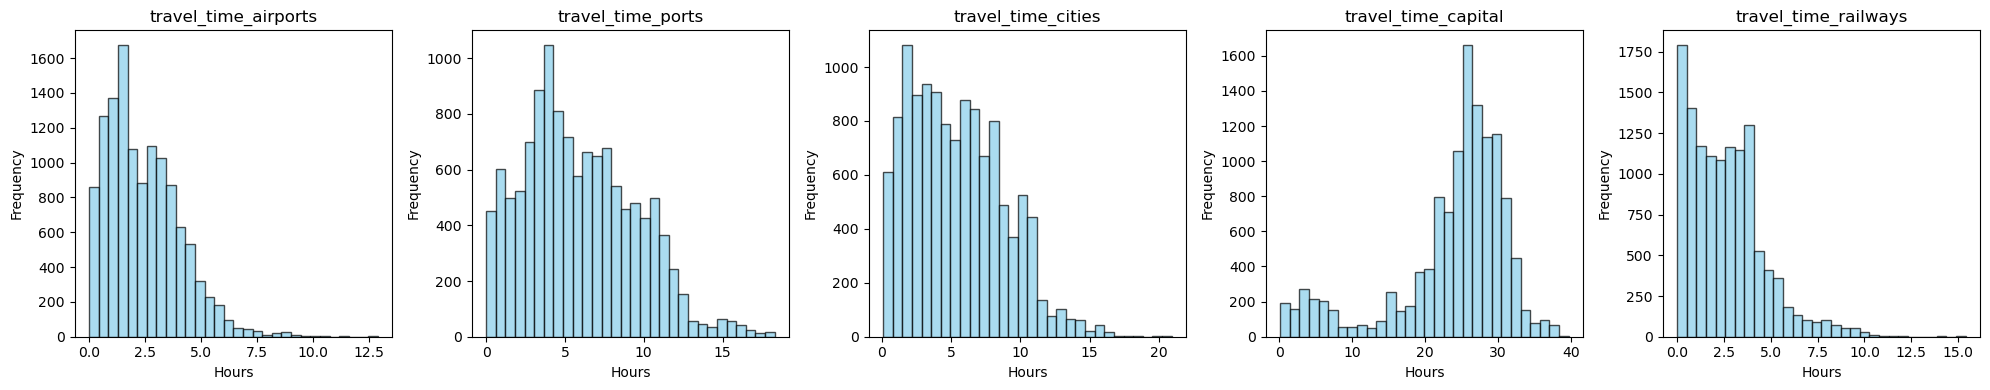

In [9]:
import matplotlib.pyplot as plt

cols = ['travel_time_airports', 'travel_time_ports',
        'travel_time_cities', 'travel_time_capital',
        'travel_time_railways']

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False)  # 5 plots in one row

for i, col in enumerate(cols):
    ax = axes[i]
    settles_gdf[col].plot.hist(ax=ax, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('Hours')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


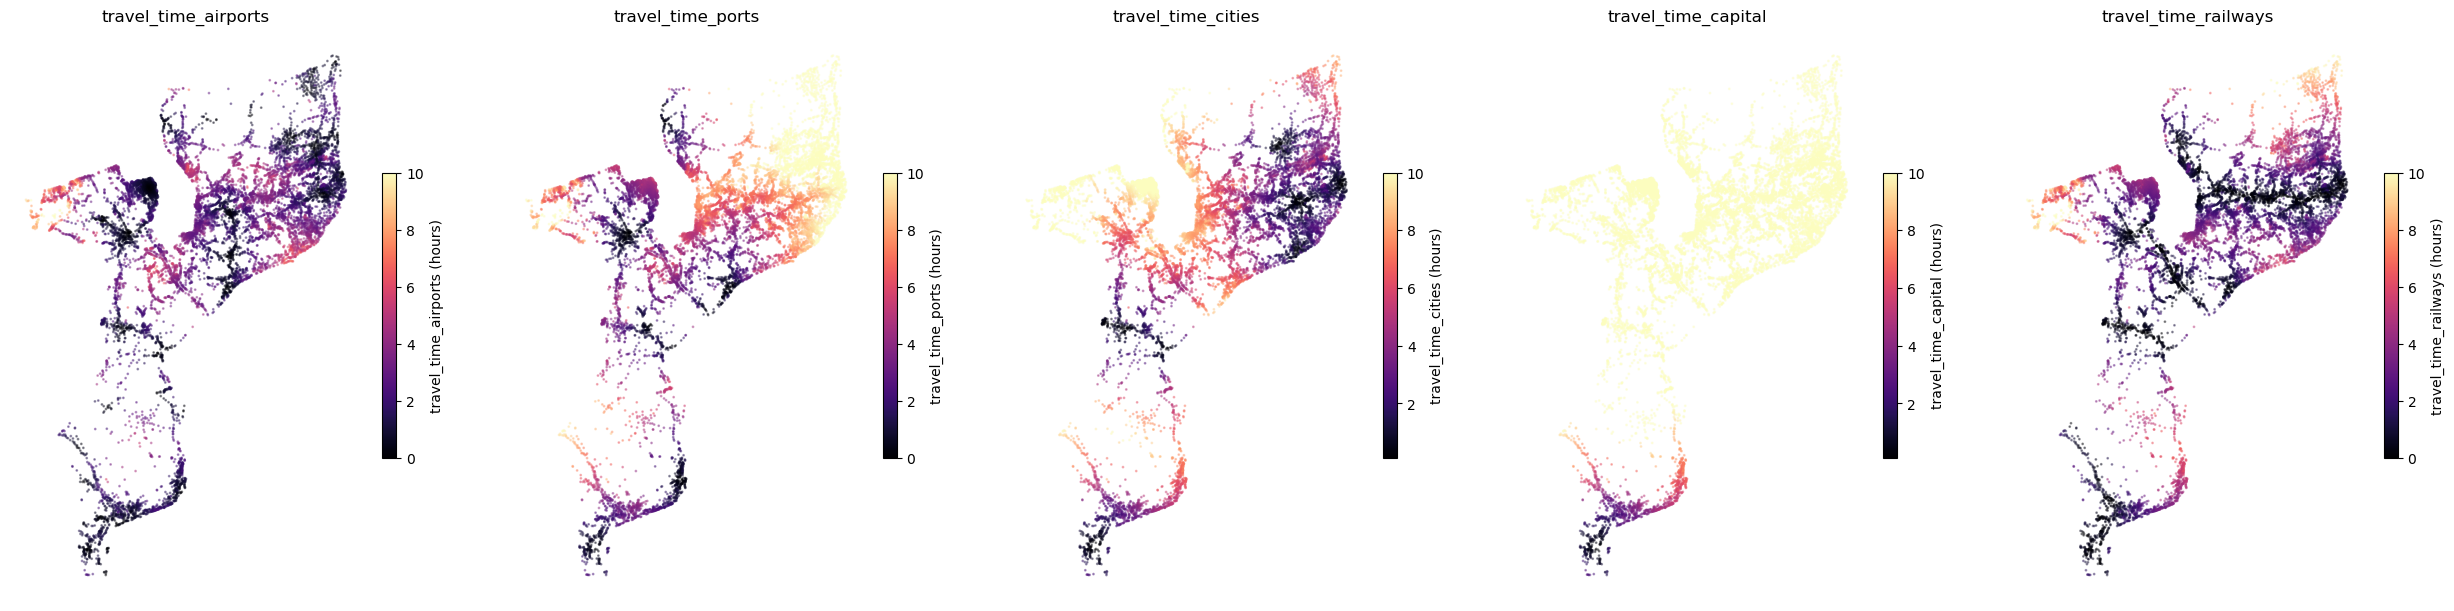

In [10]:
import matplotlib.pyplot as plt

cols = ['travel_time_airports', 'travel_time_ports',
        'travel_time_cities', 'travel_time_capital',
        'travel_time_railways']

# Create a copy and set geometry to centroids of polygons
centroids_gdf = settles_gdf.copy()
centroids_gdf.geometry = centroids_gdf.geometry.centroid

fig, axes = plt.subplots(1, 5, figsize=(25, 6), constrained_layout=True)

for ax, col in zip(axes, cols):
    centroids_gdf.plot(
        column=col,
        ax=ax,
        legend=True,
        cmap='magma',
        vmax=10,
        alpha=0.4, # Set upper boundary of colormap
        #edgecolor='black',   # for points this edgecolor does not show borders but can keep
        legend_kwds={'shrink': 0.5, 'label': f'{col} (hours)'},
        markersize=1          # larger marker size for points
    )
    ax.set_title(col)
    ax.set_axis_off()

plt.show()


In [11]:
fig = plot_histogram_map(settles_gdf, default_column='pop_20km', figure_title='Population within 20 km (before transformation)', point_size=2.5, point_opacity=0.5)

The population within 20km radius is usually very skewed to the left, due to the extremely high population around big cities. A simple min-max normalization would make the variable insignificant for most of the settlements in wheighted averages calculations. Therefore, it is required to reduce outlier effects in skewed data, and in this case it is done by applying a winsorization transformation.

In [12]:
#Winsorization for handling outlier
from scipy.stats.mstats import winsorize
settles_gdf['pop_20km_clipped']= winsorize(settles_gdf['pop_20km'] , limits=(0, 0.10))
#clipping method . CLip to 400,000
# settles_gdf['pop_20km_clipped'] = settles_gdf['pop_20km'].clip(upper=400000)

In [13]:
fig = plot_histogram_map(settles_gdf, default_column='pop_20km_clipped', figure_title='Population within 20 km (after transformation)', point_size=2.5, point_opacity=0.5)

### Market Accessibility Index (MAI) for Post-Harvest Cooling Demand Index (Export Market)

In [14]:
settles_gdf['MAI_PH_exp']= Create_MAI(
    settles_gdf,
    airport_dist_col='travel_time_airports',
    port_dist_col='travel_time_ports',
    railway_dist_col='travel_time_railways',
    capital_dist_col='travel_time_capital',
    cities_dist_col='travel_time_cities',
    pop_20km_col='pop_20km_clipped',
    airport_dist_w=0.25,
    port_dist_w=0.25,
    railway_dist_w=0.25,
    capital_dist_w=0.25,
    cities_dist_w=0,
    pop_20km_w=0,
)           

In [15]:
#transformation to reduce skewness
settles_gdf['MAI_PH_exp'] = settles_gdf['MAI_PH_exp'] ** 2

In [16]:
fig = plot_histogram_map(settles_gdf, default_column='MAI_PH_exp', figure_title='Market Accessibility Index (MAI) for Post-Harvest Cooling Demand Index (Export Market)', point_size=2.5, point_opacity=0.5)

### Market Accessibility Index (MAI) for Post-Harvest Cooling Demand Index (National Distribution)

In [17]:
settles_gdf['MAI_PH_nat']= Create_MAI(
    settles_gdf,
    airport_dist_col='travel_time_airports',
    port_dist_col='travel_time_ports',
    railway_dist_col='travel_time_railways',
    capital_dist_col='travel_time_capital',
    cities_dist_col='travel_time_cities',
    pop_20km_col='pop_20km_clipped',
    airport_dist_w=0.1,
    port_dist_w=0.1,
    railway_dist_w=0.1,
    capital_dist_w=0.3,
    cities_dist_w=0.3,
    pop_20km_w=0.1,
)

In [18]:
#transformation to reduce skewness
settles_gdf['MAI_PH_nat'] = settles_gdf['MAI_PH_nat'] ** 2

In [19]:
fig = plot_histogram_map(settles_gdf, default_column='MAI_PH_nat', figure_title='Market Accessibility Index (MAI) for Post-Harvest Cooling Demand Index (National Distribution)', point_size=2.5, point_opacity=0.5)

### Market Accessibility Index (MAI) for Post-Harvest Cooling Demand Index (Fresh Markets)

In [20]:
settles_gdf['MAI_PH_fre']= Create_MAI(
    settles_gdf,
    airport_dist_col='travel_time_airports',
    port_dist_col='travel_time_ports',
    railway_dist_col='travel_time_railways',
    capital_dist_col='travel_time_capital',
    cities_dist_col='travel_time_cities',
    pop_20km_col='pop_20km_clipped',
    airport_dist_w=0,
    port_dist_w=0,
    railway_dist_w=0,
    capital_dist_w=0,
    cities_dist_w=0.2,
    pop_20km_w=0.8,
)

In [21]:
fig = plot_histogram_map(settles_gdf, default_column='MAI_PH_fre', figure_title='Market Accessibility Index (MAI) for Post-Harvest Cooling Demand Index (Fresh Markets)', point_size=2.5, point_opacity=0.5)

## Farming activity index
Compute the farming activity index, which is a proxy for farming activity, based on:
1. Farming volume: Cropland area within each settlement's influence area (Voronoi polygon)
2. Farming density: Percentage of each settlement's influence area (Voronoi polygon) occupied by crops


In [22]:
settles_gdf= create_FAI(settles_gdf,'Crop%','Cropland_ha')

In [23]:
fig = plot_histogram_map(settles_gdf, default_column='FAI_norm', figure_title='Farming activity index', point_size=2.5, point_opacity=0.5)

## Post-Harvest Cooling Demand Indices

### Post-Harvest Cooling Demand Index (Export Market)

In [24]:
#Assign weights
FAI_w=0.4
avg_temp_w=0.2
MAI_PH_exp_w=0.4

#calculate composite index
DI_COOL_PH_exp=composite_index(
    [
        settles_gdf['FAI_norm'],
        settles_gdf['annual_avg_temp'],
        settles_gdf['MAI_PH_exp'],
    ],
    [FAI_w, avg_temp_w, MAI_PH_exp_w],
    normalize_output=True
)

settles_gdf['DI_COOL_PH_exp']=DI_COOL_PH_exp

In [25]:
fig = plot_histogram_map(settles_gdf, default_column='DI_COOL_PH_exp', figure_title='Post-Harvest Cooling Demand Index (Export Market)', point_size=2.5, point_opacity=0.5)

### Post-Harvest Cooling Demand Index (National Distribution)

In [26]:
#Assign weights
FAI_w=0.4
avg_temp_w=0.2
MAI_PH_nat_w=0.4

#calculate composite index
DI_COOL_PH_nat=composite_index(
    [
        settles_gdf['FAI_norm'],
        settles_gdf['annual_avg_temp'],
        settles_gdf['MAI_PH_nat'],
    ],
    [FAI_w, avg_temp_w, MAI_PH_nat_w],
    normalize_output=True
)

settles_gdf['DI_COOL_PH_nat']=DI_COOL_PH_nat

In [27]:
fig = plot_histogram_map(settles_gdf, default_column='DI_COOL_PH_nat', figure_title='Post-Harvest Cooling Demand Index (National Distribution)', point_size=2.5, point_opacity=0.5)

### Post-Harvest Cooling Demand Index (Fresh Markets)

In [28]:
#Assign weights
FAI_w=0.4
avg_temp_w=0.2
MAI_PH_fre_w=0.4

#calculate composite index
DI_COOL_PH_fre=composite_index(
    [
        settles_gdf['FAI_norm'],
        settles_gdf['annual_avg_temp'],
        settles_gdf['MAI_PH_fre'],
    ],
    [FAI_w, avg_temp_w, MAI_PH_fre_w],
    normalize_output=True
)

settles_gdf['DI_COOL_PH_fre']=DI_COOL_PH_fre

In [29]:
fig = plot_histogram_map(settles_gdf, default_column='DI_COOL_PH_fre', figure_title='Post-Harvest Cooling Demand Index (Fresh Markets)', point_size=2.5, point_opacity=0.5)

### Post-Harvest Cooling Demand Index (All markets)

In [30]:
#Assign weights
w_PHCDI_exp = 1/3
w_PHCDI_nat = 1/3
w_PHCDI_fre = 1/3


DI_COOL_PH_all=composite_index(
    [
        settles_gdf['DI_COOL_PH_exp'],
        settles_gdf['DI_COOL_PH_nat'],
        settles_gdf['DI_COOL_PH_fre'],
    ],
    [w_PHCDI_exp, w_PHCDI_nat, w_PHCDI_fre],
    normalize_output=True
)

settles_gdf['DI_COOL_PH_all']=DI_COOL_PH_all

In [31]:
fig = plot_histogram_map(settles_gdf, default_column='DI_COOL_PH_all', figure_title='Post-Harvest Cooling Demand Index (All markets)', point_size=2.5, point_opacity=0.5)

## Fishing Activity Index

This section creates the following indices:
- **FishAI_mar**:    Marine fishing activity index
- **FishAI_in**:	Inland fishing activity index
- **FishAI**:	Fishing activity index, both marine and inland


### Marine Fishing Activity Index

In [32]:
# Calculate FishAI_mar and store as a new column
settles_gdf['FishAI_mar'] = np.where(
    settles_gdf['shoreline_dist'] > 10,
    0,
    10 - settles_gdf['shoreline_dist']
)
settles_gdf['FishAI_mar_norm']=normalize_series(settles_gdf['FishAI_mar'])

In [33]:
#convert zeroes into NULL
settles_gdf['FishAI_mar_norm'] = settles_gdf['FishAI_mar_norm'].replace(0, np.nan)

In [34]:
fig = plot_histogram_map(settles_gdf, default_column='FishAI_mar_norm', figure_title='Marine fishing activity index', point_size=4, point_opacity=0.5)

In [35]:
import matplotlib.pyplot as plt
import geopandas as gpd

def plot_marine_fishing_activity(settles_gdf, default_column, figure_title):
    fig, (ax_map, ax_hist) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios':[4,1]})

    # Plot the map
    map_plot = settles_gdf.plot(column=default_column, ax=ax_map, legend=True, cmap='viridis')
    ax_map.set_axis_off()

    # Remove subplot title for map
    ax_map.set_title('')

    # Histogram plot for the column data below the map
    settles_gdf[default_column].plot.hist(ax=ax_hist, bins=30, color='gray')
    
    # Remove x axis label and subplot title for histogram
    ax_hist.set_xlabel('')
    ax_hist.set_title('')

    # Minimize vertical space between subplots
    fig.subplots_adjust(hspace=0.05)

    # Set main figure title
    fig.suptitle(figure_title, fontsize=16)

    # Adjust colorbar: place below the map, horizontal and thinner
    # Remove original colorbar created by geopandas plot
    for cbar in ax_map.get_figure().axes:
        if cbar != ax_map and cbar != ax_hist:
            cbar.remove()

    # Create new colorbar manually
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax_map)
    cax = divider.append_axes("bottom", size="5%", pad=0.5)

    # Plot the map again for colorbar reference
    norm = plt.Normalize(settles_gdf[default_column].min(), settles_gdf[default_column].max())
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.ax.tick_params(size=0)
    cbar.outline.set_linewidth(1)
    cbar.ax.set_title('')
    cbar.ax.xaxis.set_label_position('bottom')
    cbar.ax.tick_params(labelsize=8)
    cbar.set_ticks([])  # Optional: remove ticks if you want an even cleaner bar

    plt.show()


### Inland Fishing Activity Index

In [36]:
fig = plot_histogram_map(settles_gdf, default_column='permanent_water_within10km', figure_title='Permanent water within 10km', point_size=4, point_opacity=0.5)

In [37]:
settles_gdf['permanent_water_within10km_norm']=normalize_series(settles_gdf['permanent_water_within10km'])

settles_gdf['FishAI_in'] = np.where(
    (settles_gdf['permanent_water_within10km'] < 1) | (settles_gdf['shoreline_dist'] < 10),
    0,
    settles_gdf['permanent_water_within10km_norm']
)

#settles_gdf.drop(columns=['permanent_water_within10km_norm'], inplace=True)
settles_gdf['FishAI_in_norm']=normalize_series(settles_gdf['FishAI_in'])

#convert zeroes into NULL
settles_gdf['FishAI_in_norm'] = settles_gdf['FishAI_in_norm'].replace(0, np.nan)

In [38]:
fig = plot_histogram_map(settles_gdf, default_column='FishAI_in_norm', figure_title='Inland fishing activity index', point_size=4, point_opacity=0.5)

Since the distribution is highly skewed (positive skew), this index cannot be used as it is and needs to be transformed to bring its distribution closer to a normal distribution. Here, we use the **Yeo-Johnson transformation**, a statistical method designed to stabilize variance and make data more closely resemble a normal distribution. The algorithm works by estimating the optimal lambda parameter for the Yeo-Johnson transformation, then applying the transformation to the data. Subsequently, a new min-max normalization is applied to bring the transformed data back to a 0 to 1 scale, making it easier to interpret

In [39]:
#Apply Yeo-Johnson transformation

from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# Apply Yeo-Johnson transformation
yeo_johnson = PowerTransformer(method='yeo-johnson')
transformed_data = yeo_johnson.fit_transform(settles_gdf[['FishAI_in_norm']])

# Normalize to 0–1
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(transformed_data)

# Assign back to your DataFrame
settles_gdf['FishAI_in_norm'] = normalized_data

In [40]:
#convert zeroes into NULL
settles_gdf['FishAI_in_norm'] = settles_gdf['FishAI_in_norm'].replace(0, np.nan)

In [41]:
fig = plot_histogram_map(settles_gdf, default_column='FishAI_in_norm', figure_title='Inland fishing activity index - transformed to reduce skewness', point_size=4, point_opacity=0.5)

### Fishing Activity Index (combined marine and inland)

The final fishing activity index is the maximum between the inland and the marine fishing activity indices.

In [42]:
# Apply np.maximum and normalize
settles_gdf['FishAI_norm'] = normalize_series(np.maximum(settles_gdf['FishAI_in_norm'].fillna(0), settles_gdf['FishAI_mar_norm'].fillna(0)))
#convert zeroes into NULL
settles_gdf['FishAI_norm'] = settles_gdf['FishAI_norm'].replace(0, np.nan)


In [43]:
fig = plot_histogram_map(settles_gdf, default_column='FishAI_norm', figure_title='Fishing Activity Index (combined marine and inland)', point_size=4, point_opacity=0.5)

Compute a column to categorize fishing activity in each settlement: "marine", "inland", "marine and inland", "none"

In [44]:
conditions = [
    (settles_gdf['FishAI_in_norm'].notnull()) & (settles_gdf['FishAI_mar_norm'].notnull()),
    (settles_gdf['FishAI_in_norm'].notnull()) & (settles_gdf['FishAI_mar_norm'].isnull()),
    (settles_gdf['FishAI_in_norm'].isnull()) & (settles_gdf['FishAI_mar_norm'].notnull()),
    (settles_gdf['FishAI_in_norm'].isnull()) & (settles_gdf['FishAI_mar_norm'].isnull())
]

choices = [
    'marine and inland',
    'inland',
    'marine',
    'none'
]

settles_gdf['Fish_AI_cat'] = np.select(conditions, choices, default='none')

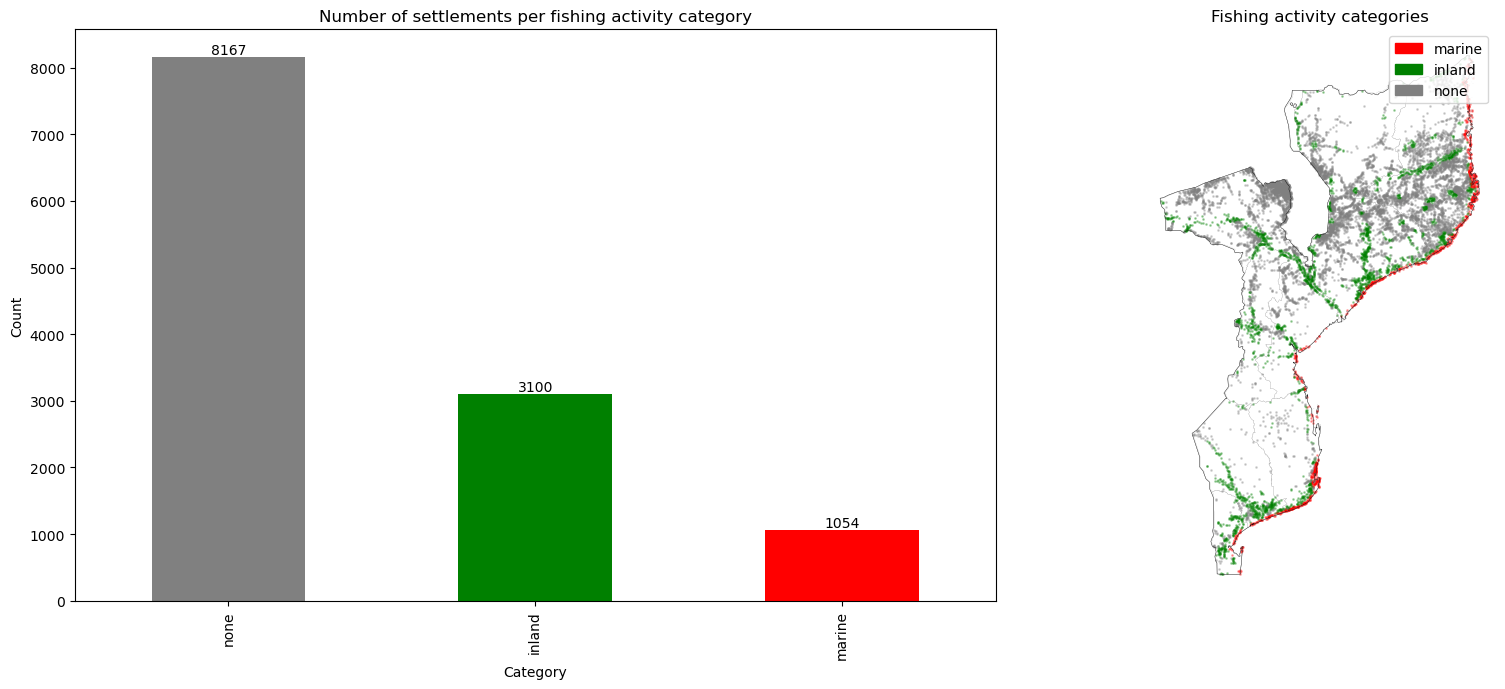

In [45]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Create a copy and set geometry to centroids
centroids_gdf = settles_gdf.copy()
centroids_gdf.geometry = centroids_gdf.geometry.centroid

# Define colors for each category
color_map = {
    'marine': 'red',
    'inland': 'green',
    'none': 'gray'
}

# Create figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left plot: histogram (bar chart) of category counts with labels
ax_hist = axes[0]
category_counts = settles_gdf['Fish_AI_cat'].value_counts()
bars = category_counts.plot.bar(ax=ax_hist, color=[color_map.get(cat, 'gray') for cat in category_counts.index])

# Add value labels on top of each bar
ax_hist.bar_label(bars.containers[0], labels=category_counts.values, label_type='edge')

ax_hist.set_title('Number of settlements per fishing activity category')
ax_hist.set_xlabel('Category')
ax_hist.set_ylabel('Count')

# Right plot: map of centroids colored by category
ax_map = axes[1]

# Plot each category with a different color
for category, color in color_map.items():
    subset = centroids_gdf[centroids_gdf['Fish_AI_cat'] == category]
    subset.plot(ax=ax_map, color=color, label=category, alpha=0.3, markersize=1)

# Plot adm0 and adm1 boundaries on the same map axis
adm_0.boundary.plot(ax=ax_map, edgecolor='black', linewidth=0.3)
adm_1.boundary.plot(ax=ax_map, edgecolor='gray', linewidth=0.1)

# Add legend
legend_patches = [mpatches.Patch(color=color, label=category) for category, color in color_map.items()]
ax_map.legend(handles=legend_patches, loc='upper right')
ax_map.set_title('Fishing activity categories')
ax_map.set_axis_off()

plt.tight_layout()
plt.show()


## Fish Cooling Demand Indices

### Fish Cooling Demand Index (Export Market)

In [46]:
#Assign weights
FishAI_norm_w=0.4
avg_temp_w=0.2
MAI_PH_exp_w=0.4

#calculate composite index
DI_COOL_FISH_exp=composite_index(
    [
        settles_gdf['FishAI_norm'],
        settles_gdf['annual_avg_temp'],
        settles_gdf['MAI_PH_exp'],
    ],
    [FishAI_norm_w, avg_temp_w, MAI_PH_exp_w],
    normalize_output=True
)

settles_gdf['DI_COOL_FISH_exp']=DI_COOL_FISH_exp

In [47]:
fig = plot_histogram_map(settles_gdf, default_column='DI_COOL_FISH_exp', figure_title='Fish Cooling Demand Index (Export Market)', point_size=4, point_opacity=0.5)

### Fish Cooling Demand Index (National Distribution)

In [48]:
#Assign weights
FishAI_norm_w=0.4
avg_temp_w=0.2
MAI_PH_nat_w=0.4

#calculate composite index
DI_COOL_FISH_nat=composite_index(
    [
        settles_gdf['FishAI_norm'],
        settles_gdf['annual_avg_temp'],
        settles_gdf['MAI_PH_nat'],
    ],
    [FishAI_norm_w, avg_temp_w, MAI_PH_exp_w],
    normalize_output=True
)

settles_gdf['DI_COOL_FISH_nat']=DI_COOL_FISH_nat

In [49]:
fig = plot_histogram_map(settles_gdf, default_column='DI_COOL_FISH_nat', figure_title='Fish Cooling Demand Index (National Distribution)', point_size=4, point_opacity=0.5)

### Fish Cooling Demand Index (Fresh Markets)

In [50]:
#Assign weights
FishAI_norm_w=0.4
avg_temp_w=0.2
MAI_PH_fre_w=0.4

#calculate composite index
DI_COOL_FISH_fre=composite_index(
    [
        settles_gdf['FishAI_norm'],
        settles_gdf['annual_avg_temp'],
        settles_gdf['MAI_PH_fre'],
    ],
    [FishAI_norm_w, avg_temp_w, MAI_PH_exp_w],
    normalize_output=True
)

settles_gdf['DI_COOL_FISH_fre']=DI_COOL_FISH_fre

In [51]:
fig = plot_histogram_map(settles_gdf, default_column='DI_COOL_FISH_fre', figure_title='Fish Cooling Demand Index (Fresh Markets)', point_size=4, point_opacity=0.5)

### Post-Harvest Cooling Demand Index (All markets)

In [52]:
#Assign weights
w_FCDI_exp = 1/3
w_FCDI_nat = 1/3
w_FCDI_fre = 1/3

DI_COOL_FISH_all=composite_index(
    [
        settles_gdf['DI_COOL_FISH_exp'],
        settles_gdf['DI_COOL_FISH_nat'],
        settles_gdf['DI_COOL_FISH_fre'],
    ],
    [w_FCDI_exp, w_FCDI_nat, w_FCDI_fre],
    normalize_output=True
)

settles_gdf['DI_COOL_FISH_all']=DI_COOL_FISH_all

In [53]:
fig = plot_histogram_map(settles_gdf, default_column='DI_COOL_FISH_all', figure_title='Fish Cooling Demand Index (ALL Markets)', point_size=4, point_opacity=0.5)

# Cleaning and formatting data for visualization and export

In [54]:
# Round decimals
settles_gdf_rounded = settles_gdf.round(3)

In [55]:
# Print column names (activate it if need to copy / export column names)
print(*settles_gdf.columns, sep='\n')

NL
Population
Buildings
DEGURBA
Area
id
Country
FinalElecCode2024
FinalElecCode2030
IEP_Result2024
IEP_Result2030
building_count
settl_area_km2
Province
District
Posto
Localidade
pop_2025
pop_dens_pp_km2
pop_20km
MV_linesDist
MGDist
nightlights
Electrification status nightlights
rwi
food_insec_perc
livelihoods
conflict_fatalities_last_2y
elevation
annual_avg_temp
CDD_4C
hot_days_above_30
rel_humidity
precipitation_mm
pvout
mean_diurnal_temp_range
cyclonHaz_1in100_wind_kmh
aridity_index
climate_class
travel_time_airports
travel_time_ports
travel_time_cities
travel_time_capital
travel_time_railways
shoreline_dist
permanent_water_within10km
Cropland_ha
Crop%
Banana_prod_t_year
Cassava_prod_t_year
Citrus_prod_t_year
Cashew_Nut_prod_t_year
Cotton_prod_t_year
Maiz_prod_t_year
Other_Roots_prod_t_year
Plantain_prod_t_year
Potato_prod_t_year
Rice_prod_t_year
Sorghum_prod_t_year
Sugarcane_prod_t_year
Sweet_Potato_prod_t_year
Temperate_Fruit_prod_t_year
Tobacco_prod_t_year
Other_Tropical_Fruit_pr

In [56]:
## generate rename_dict for renaming columns (activate if renaming needs to be changed)
# rename_dict={col:col for col in columns}
# rename_dict

In [57]:
# Rename the columns before export
rename_dict={
 'id': 'id', 
 'Population': 'Population (from IEP)',
 'NL': 'Nightlight (from IEP)',
 'Area': 'Cluster Area (from IEP)',
 'settl_area_km2': 'Cluster Area in km2',
 'DEGURBA': 'Urbanization Status',
 'Buildings': 'Buildings (from IEP)',
 'building_count': 'Buildings', 
 'Region': 'Region',
 'District': 'District',
 'Postos': 'Postos',
 'Postos_INE': 'Postos_INE',
 'pop_2025': 'Population 2025',
 'pop_dens_pp_km2': 'Population density',
 'pop_20km': 'Population within 20 km',
 'MV_linesDist': 'Distance from MV power lines',
 'MGDist': 'Distance from nearest mini-grid',
 'nightlights': 'Night lights intensity',
 'Electrification_status_nightlights': 'Electrification status (nightlights)',
 'FinalElecCode2024': 'Electrification status (IEP study)',
 'FinalElecCode2030': 'Least-cost electrification mode (IEP results)',
 'NewCapacityTotal': 'Least-cost elec. New Capacity (kW)',
 'LCOETotal': 'Least-cost elec. Generating Cost ($/kWh)',
 'rwi': 'Relative Wealth Index',
 'food_insec_perc': 'Percentage of food-insecure people',
 'livelihoods': 'Livelihoods',
 'conflict_fatalities_last_2y': 'Conflict fatalities nearby',
 'elevation': 'Elevation',
 'annual_avg_temp': 'Mean temperature',
 'CDD_4C': 'Cooling Degree Days Cold Room at 4C',
 'hot_days_above_30': 'Hot days (>30C) in a year',
 'rel_humidity': 'Relative humidity',
 'precipitation_mm': 'Precipitation',
 'pvout': 'Solar PV Output (kWh/year per installed kW)',
 'mean_diurnal_temp_range': 'Mean diurnal temperature range',
 'cyclonHaz_1in100_wind_kmh': 'Cyclone hazard (1 in 100 years wind speed)',
 'aridity_index': 'Aridity Index',
 'climate_class': 'Climate class',
 'travel_time_airports': 'Travel time airports',
 'travel_time_ports': 'Travel time ports',
 'travel_time_cities': 'Travel time cities',
 'travel_time_capital': 'Travel time capital',
 'travel_time_railways': 'Travel time railway stations',
 'shoreline_dist': 'Distance from coastlines',
 'ShoreWithin10km': 'Shorelines within 10 km',
 'permanent_water_within10km': 'Permanent water area (ha) within 10 km',
 'Vor_area_sq.km': 'Influence area km2',
 'Vor_area_ha': 'Influence area ha',
 'Cropland_ha': 'Cropland area ha',
 'Crop%': 'Cropland percentage of Influence area',
 'Banana_prod_t_year': 'Banana production',
 'Cassava_prod_t_year': 'Cassava production',
 'Citrus_prod_t_year': 'Citrus production',
 'Cashew_Nut_prod_t_year': 'Cashew Nut production',
 'Cotton_prod_t_year': 'Cotton production',
 'Maiz_prod_t_year': 'Maize production',
 'Other_Roots_prod_t_year': 'Other Roots & Tubers production',
 'Plantain_prod_t_year': 'Plantain production',
 'Potato_prod_t_year': 'Potato production',
 'Rice_prod_t_year': 'Rice production',
 'Sorghum_prod_t_year': 'Sorghum production',
 'Sugarcane_prod_t_year': 'Sugarcane production',
 'Sweet_Potato_prod_t_year': 'Sweet Potato production',
 'Temperate_Fruit_prod_t_year': 'Temperate Fruit production',
 'Tobacco_prod_t_year': 'Tobacco production',
 'Other_Tropical_Fruit_prod_t_year': 'Tropical Fruit production',
 'Vegetables_prod_t_year': 'Vegetables production',
 'Tomato_prod_t_year': 'Tomato production',   
 'geometry': 'geometry',
 'pop_20km_clipped': 'Population within 20 km clipped',
 'MAI_PH_exp': 'Export Market Accessibility',
 'MAI_PH_nat': 'National Market Accessibility',
 'MAI_PH_fre': 'Fresh Markets Accessibility',
 'FAI': 'FAI',
 'FAI_norm': 'Farming Activity',
 'DI_COOL_PH_exp': 'Ag Cooling Demand Export Market',
 'DI_COOL_PH_nat': 'Ag Cooling Demand National Market',
 'DI_COOL_PH_fre': 'Ag Cooling Demand Fresh Markets',
 'DI_COOL_PH_all': 'Ag Cooling Demand ALL Markets',
 'FishAI_mar': 'FishAI_mar',
 'FishAI_mar_norm': 'Marine Fishing Activity',
 'permanent_water_within10km_norm': 'permanent_water_within10km_norm',
 'FishAI_in': 'FishAI_in',
 'FishAI_in_norm': 'Inland Fishing Activity',
 'FishAI_norm': 'Fishing Activity (marine + inland)',
 'Fish_AI_cat': 'Fishing type',
 'DI_COOL_FISH_exp': 'Fish Cooling Demand Export Market',
 'DI_COOL_FISH_nat': 'Fish Cooling Demand National Market',
 'DI_COOL_FISH_fre': 'Fish Cooling Demand Fresh Markets',
 'DI_COOL_FISH_all': 'Fish Cooling Demand ALL Markets'
 }

settles_gdf_renamed = settles_gdf_rounded.rename(columns=rename_dict)

In [58]:
settles_gdf_renamed.head(2)

,Nightlight (from IEP),Population (from IEP),Buildings (from IEP),Urbanization Status,Cluster Area (from IEP),id,Country,Electrification status (IEP study),Least-cost electrification mode (IEP results),IEP_Result2024,IEP_Result2030,Buildings,Cluster Area in km2,Province,District,Posto,Localidade,Population 2025,Population density,Population within 20 km,Distance from MV power lines,Distance from nearest mini-grid,Night lights intensity,Electrification status nightlights,Relative Wealth Index,Percentage of food-insecure people,Livelihoods,Conflict fatalities nearby,Elevation,Mean temperature,Cooling Degree Days Cold Room at 4C,Hot days (>30C) in a year,Relative humidity,Precipitation,Solar PV Output (kWh/year per installed kW),Mean diurnal temperature range,Cyclone hazard (1 in 100 years wind speed),Aridity Index,Climate class,Travel time airports,Travel time ports,Travel time cities,Travel time capital,Travel time railway stations,Distance from coastlines,Permanent water area (ha) within 10 km,Cropland area ha,Cropland percentage of Influence area,Banana production,Cassava production,Citrus production,Cashew Nut production,Cotton production,Maize production,Other Roots & Tubers production,Plantain production,Potato production,Rice production,Sorghum production,Sugarcane production,Sweet Potato production,Temperate Fruit production,Tobacco production,Tropical Fruit production,Vegetables production,Tomato production,geometry,Population within 20 km clipped,Export Market Accessibility,National Market Accessibility,Fresh Markets Accessibility,FAI,Farming Activity,Ag Cooling Demand Export Market,Ag Cooling Demand National Market,Ag Cooling Demand Fresh Markets,Ag Cooling Demand ALL Markets,FishAI_mar,Marine Fishing Activity,permanent_water_within10km_norm,FishAI_in,Inland Fishing Activity,Fishing Activity (marine + inland),Fishing type,Fish Cooling Demand Export Market,Fish Cooling Demand National Market,Fish Cooling Demand Fresh Markets,Fish Cooling Demand ALL Markets
0,0.0,88.13,144,Low Density Rural,0.521,4,Mozambique,99,3,Non Electrified,SHS,144,0.445,GAZA,CHICUALACUALA,PAFURI,Mbuzi,88,197,1902,258.089,14.029,0.2,likely electrified,NaN,NaN,Limpopo and Elephant Rivers Mixed Cropping,0,210.0,24.3,7410,178.0,57.0,496.0,1926,1.5,66,0.22,"BSh Arid, steppe, hot",1.5,9.2,9.1,9.2,1.5,363.7,0.4,72.323,0.329,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((31.47039 -22.47395, 31.47112 -22.473...",1902,0.573,0.381,0.114,0.003,0.005,0.347,0.255,0.135,0.239,0.0,NaN,0.0,0.0,NaN,NaN,none,NaN,NaN,NaN,NaN
1,0.0,117.46,339,Low Density Rural,0.650,10,Mozambique,99,3,Non Electrified,SHS,339,0.556,GAZA,CHICUALACUALA,PAFURI,Mbuzi,118,212,1934,262.730,8.476,0.2,likely electrified,NaN,NaN,Limpopo and Elephant Rivers Mixed Cropping,0,204.0,24.3,7410,178.0,57.0,496.0,1922,1.5,66,0.22,"BSh Arid, steppe, hot",1.6,9.3,9.2,9.3,1.6,368.0,0.4,33.734,0.291,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((31.40961 -22.45221, 31.41106 -22.452...",1934,0.564,0.376,0.113,0.002,0.003,0.341,0.252,0.133,0.236,0.0,NaN,0.0,0.0,NaN,NaN,none,NaN,NaN,NaN,NaN


In [59]:
### generate list of renamed columns for reordering columns (activate if order needs to be changed)
# settles_gdf_renamed.columns.tolist()

In [61]:
## Reorder columns
## reorder manually the column names; comment to drop a column

desired_order=[
# Administrative & Location
 'id',
 'Country', 
 'Province',
 'District',
 'Posto',
 'Localidade',
 'Urbanization Status',
 'Cluster Area (from IEP)',
 'Cluster Area in km2',
# Population & Demographics
 'Population (from IEP)',
 'Population 2025',
 'Population density',
 'Population within 20 km',
 'Buildings (from IEP)',
 'Buildings',  
# Electrification
 'Distance from MV power lines',
 'Distance from nearest mini-grid',
 'Nightlight (from IEP)',
 'Night lights intensity',
 'Electrification status nightlights',
 'Electrification status (IEP study)',
 'Least-cost electrification mode (IEP results)',
# 'Least-cost elec. New Capacity (kW)',
# 'Least-cost elec. Generating Cost ($/kWh)',
# Economic, Livelihoods, and Risks
 'Relative Wealth Index',
 'Percentage of food-insecure people',
 'Livelihoods',
 'Conflict fatalities nearby',
 'Cyclone hazard (1 in 100 years wind speed)',
# Physical Geography & Climate
 'Elevation',
 'Mean temperature',
 'Mean diurnal temperature range',
 'Cooling Degree Days Cold Room at 4C',
 'Hot days (>30C) in a year',
 'Relative humidity',
 'Precipitation',
 'Aridity Index',
 'Climate class',
 'Solar PV Output (kWh/year per installed kW)',
# Water & Cropland
 #'Influence area km2',
 #'Influence area ha',
 'Cropland area ha',
 'Cropland percentage of Influence area',
 'Permanent water area (ha) within 10 km',
  #'permanent_water_within10km_norm',
 'Distance from coastlines',
 #'Shorelines within 10 km',
# Market Accessibility
 'Travel time airports',
 'Travel time ports',
 'Travel time cities',
 'Travel time capital',
 'Travel time railway stations',
 'Export Market Accessibility',
 'National Market Accessibility',
 'Fresh Markets Accessibility',
# Agricultural Cooling Demand
 #'FAI',
 'Farming Activity',
 'Ag Cooling Demand Export Market',
 'Ag Cooling Demand National Market',
 'Ag Cooling Demand Fresh Markets',
 'Ag Cooling Demand ALL Markets',
# Agriculture Production
 'Banana production',
 'Cassava production',
 'Citrus production',
 'Cashew Nut production',
 'Cotton production',
 'Maize production',
 'Other Roots & Tubers production',
 'Plantain production',
 'Potato production',
 'Rice production',
 'Sorghum production',
 'Sugarcane production',
 'Sweet Potato production',
 'Temperate Fruit production',
 'Tobacco production',
 'Tropical Fruit production',
 'Vegetables production',
 'Tomato production',    
# Fishing Cooling Demand
 #'FishAI_mar',
 #'Marine Fishing Activity',
 #'FishAI_in',
 #'Inland Fishing Activity',
 'Fishing Activity (marine + inland)',
 'Fishing type',
 'Fish Cooling Demand Export Market',
 'Fish Cooling Demand National Market',
 'Fish Cooling Demand Fresh Markets',
 'Fish Cooling Demand ALL Markets',
# Geometry
 'geometry'
 ]

# Reorder the DataFrame
settles_gdf_reordered = settles_gdf_renamed[desired_order]
pd.set_option('display.max_columns', None)
settles_gdf_reordered.head(2)

,id,Country,Province,District,Posto,Localidade,Urbanization Status,Cluster Area (from IEP),Cluster Area in km2,Population (from IEP),Population 2025,Population density,Population within 20 km,Buildings (from IEP),Buildings,Distance from MV power lines,Distance from nearest mini-grid,Nightlight (from IEP),Night lights intensity,Electrification status nightlights,Electrification status (IEP study),Least-cost electrification mode (IEP results),Relative Wealth Index,Percentage of food-insecure people,Livelihoods,Conflict fatalities nearby,Cyclone hazard (1 in 100 years wind speed),Elevation,Mean temperature,Mean diurnal temperature range,Cooling Degree Days Cold Room at 4C,Hot days (>30C) in a year,Relative humidity,Precipitation,Aridity Index,Climate class,Solar PV Output (kWh/year per installed kW),Cropland area ha,Cropland percentage of Influence area,Permanent water area (ha) within 10 km,Distance from coastlines,Travel time airports,Travel time ports,Travel time cities,Travel time capital,Travel time railway stations,Export Market Accessibility,National Market Accessibility,Fresh Markets Accessibility,Farming Activity,Ag Cooling Demand Export Market,Ag Cooling Demand National Market,Ag Cooling Demand Fresh Markets,Ag Cooling Demand ALL Markets,Banana production,Cassava production,Citrus production,Cashew Nut production,Cotton production,Maize production,Other Roots & Tubers production,Plantain production,Potato production,Rice production,Sorghum production,Sugarcane production,Sweet Potato production,Temperate Fruit production,Tobacco production,Tropical Fruit production,Vegetables production,Tomato production,Fishing Activity (marine + inland),Fishing type,Fish Cooling Demand Export Market,Fish Cooling Demand National Market,Fish Cooling Demand Fresh Markets,Fish Cooling Demand ALL Markets,geometry
0,4,Mozambique,GAZA,CHICUALACUALA,PAFURI,Mbuzi,Low Density Rural,0.521,0.445,88.13,88,197,1902,144,144,258.089,14.029,0.0,0.2,likely electrified,99,3,NaN,NaN,Limpopo and Elephant Rivers Mixed Cropping,0,66,210.0,24.3,1.5,7410,178.0,57.0,496.0,0.22,"BSh Arid, steppe, hot",1926,72.323,0.329,0.4,363.7,1.5,9.2,9.1,9.2,1.5,0.573,0.381,0.114,0.005,0.347,0.255,0.135,0.239,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,none,NaN,NaN,NaN,NaN,"POLYGON ((31.47039 -22.47395, 31.47112 -22.473..."
1,10,Mozambique,GAZA,CHICUALACUALA,PAFURI,Mbuzi,Low Density Rural,0.650,0.556,117.46,118,212,1934,339,339,262.730,8.476,0.0,0.2,likely electrified,99,3,NaN,NaN,Limpopo and Elephant Rivers Mixed Cropping,0,66,204.0,24.3,1.5,7410,178.0,57.0,496.0,0.22,"BSh Arid, steppe, hot",1922,33.734,0.291,0.4,368.0,1.6,9.3,9.2,9.3,1.6,0.564,0.376,0.113,0.003,0.341,0.252,0.133,0.236,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,none,NaN,NaN,NaN,NaN,"POLYGON ((31.40961 -22.45221, 31.41106 -22.452..."


# Summary table

In [62]:
# Drop geometry column for stats
df = settles_gdf_reordered.drop(columns='geometry')

# Descriptive stats
summary_table = df.describe(include='all')

# Data types row
dtypes_row = df.dtypes.to_frame().T
dtypes_row.index = ['dtype']

# Count NaNs per column
nan_counts = df.isna().sum().to_frame().T
nan_counts.index = ['NaN_count']

# Count zeros per column (only numeric columns to avoid errors)
zero_counts = df.select_dtypes(include=['number']).eq(0).sum().to_frame().T
zero_counts.index = ['zero_count']

# For non-numeric columns, add zero counts as 0
non_numeric_cols = set(df.columns) - set(zero_counts.columns)
for col in non_numeric_cols:
    zero_counts[col] = 0
zero_counts = zero_counts[df.columns]  # reorder to original column order

# Count infinity values (both +inf and -inf) per column (only numeric)
inf_counts = df.select_dtypes(include=['number']).isin([np.inf, -np.inf]).sum().to_frame().T
inf_counts.index = ['inf_count']

# For non-numeric columns, add inf counts as 0
for col in set(df.columns) - set(inf_counts.columns):
    inf_counts[col] = 0
inf_counts = inf_counts[df.columns]  # reorder to original column order

# Combine all rows
summary_with_extra = pd.concat([summary_table, dtypes_row, nan_counts, zero_counts, inf_counts], axis=0)

pd.set_option('display.max_columns', None)
summary_with_extra

,id,Country,Province,District,Posto,Localidade,Urbanization Status,Cluster Area (from IEP),Cluster Area in km2,Population (from IEP),Population 2025,Population density,Population within 20 km,Buildings (from IEP),Buildings,Distance from MV power lines,Distance from nearest mini-grid,Nightlight (from IEP),Night lights intensity,Electrification status nightlights,Electrification status (IEP study),Least-cost electrification mode (IEP results),Relative Wealth Index,Percentage of food-insecure people,Livelihoods,Conflict fatalities nearby,Cyclone hazard (1 in 100 years wind speed),Elevation,Mean temperature,Mean diurnal temperature range,Cooling Degree Days Cold Room at 4C,Hot days (>30C) in a year,Relative humidity,Precipitation,Aridity Index,Climate class,Solar PV Output (kWh/year per installed kW),Cropland area ha,Cropland percentage of Influence area,Permanent water area (ha) within 10 km,Distance from coastlines,Travel time airports,Travel time ports,Travel time cities,Travel time capital,Travel time railway stations,Export Market Accessibility,National Market Accessibility,Fresh Markets Accessibility,Farming Activity,Ag Cooling Demand Export Market,Ag Cooling Demand National Market,Ag Cooling Demand Fresh Markets,Ag Cooling Demand ALL Markets,Banana production,Cassava production,Citrus production,Cashew Nut production,Cotton production,Maize production,Other Roots & Tubers production,Plantain production,Potato production,Rice production,Sorghum production,Sugarcane production,Sweet Potato production,Temperate Fruit production,Tobacco production,Tropical Fruit production,Vegetables production,Tomato production,Fishing Activity (marine + inland),Fishing type,Fish Cooling Demand Export Market,Fish Cooling Demand National Market,Fish Cooling Demand Fresh Markets,Fish Cooling Demand ALL Markets
count,12321.0,12321,12316,12316,12316,12321,12321,12321.0,12321.0,12321.0,12321.0,12321.0,12321.0,12321.0,12321.0,12321.0,12321.0,12321.0,12321.0,12321,12321.0,12321.0,11449.0,4125.0,12316,12321.0,12321.0,12309.0,12321.0,12299.0,12321.0,12297.0,12297.0,12297.0,12309.0,12316,12321.0,12242.0,12242.0,12321.0,12321.0,12321.0,12321.0,12321.0,12321.0,12321.0,12321.0,12321.0,12321.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,12242.0,4154.0,12321,4154.0,4154.0,4154.0,4154.0
unique,NaN,1,11,145,416,1130,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN
top,NaN,Mozambique,NAMPULA,ANGONIA,DOMUE,Nao Aplicavel,Low Density Rural,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,likely electrified,NaN,NaN,NaN,NaN,Northern Highland with Mixed Cropping,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Aw Tropical, savannah",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none,NaN,NaN,NaN,NaN
freq,NaN,12321,2926,588,350,319,9503,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11274,NaN,NaN,NaN,NaN,2583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8167,NaN,NaN,NaN,NaN
mean,597727.333983,NaN,NaN,NaN,NaN,NaN,NaN,1.025659,0.919718,1805.506269,1807.462462,794.429998,103317.264995,779.347212,779.347212,81.473217,58.829309,0.273161,0.289968,NaN,79.504423,4.240971,-0.389982,0.194594,NaN,2.648486,98.356546,440.889512,23.419227,1.188771,7088.01607,115.167195,68.8916,976.211434,0.606735,NaN,1982.35476,326.075223,15.962356,281.343901,217.634535,2.416265,5.93856,5.416476,23.681803,2.617426,0.461805,0.367826,0.409115,0.138079,0.339143,0.299278,0.318741,0.31578,438.91414,3536.600482,5

In [63]:
settles_gdf_analyzed=settles_gdf_reordered

# Export results for the multicriteria analysis

Export settlements. Comment the code blocks below if you don't want to overwrite any previous file that is already saved in the workspace folder. Rename the output files before any new export.
You can export in one or multiple file formats 

**UNCOMMENT TO EXPORT**

In [64]:
# ## Export to geopackage
settles_gdf_analyzed.to_file(project_root/f"data/processed/input_analyzed/settlements_analyzed_{datetime.now().strftime('%Y%m%d')}.gpkg", driver="GPKG")

Other file formats

In [65]:
# # Export to GeoJSON
# settles_gdf_reordered.to_file(workspace + r'\settles_gdf_MDG_analyzed_v2.geojson', driver='GeoJSON')
#settles_gdf_reordered.to_file(project_root/'data/processed/settles_gdf_MDG_analyzed.geojson', driver='GeoJSON')

In [ ]:
#Export as FlatGeoBuf
#settles_gdf_reordered.to_file(project_root/'data/processed/settles_gdf_MDG_analyzed.fgb', driver='FlatGeobuf')

In [ ]:
# # Export to GeoParquet
# settles_gdf_reordered.to_parquet(workspace + r'\settles_gdf_MDG_analyzed.parquet')
#settles_gdf_reordered.to_parquet(project_root/'data/processed/settles_gdf_MDG_analyzed.parquet')

Export Voronoi polygons (influence areas)

In [ ]:
#settles_gdf_reordered.to_file(project_root/'data/processed/influence_areas_MDG_analyzed.fgb',driver="GPKG")

# Visualization of results (description to be uptaded)

Currently using Kepler GL or Foursquare web mapping clients to visualize results and perform multi-criteria analysis. Alternatively, the results can be further explored in a Desktop GIS software or in Python Jupyter notebooks

**Kepler GL**: https://kepler.gl/ : completely free and open-source, but limited in analytical capabilities
1. Go to website
2. Click on "Get Started"
3. Add the data exported above to the map:
    - settles_gdf exported file (main layer, required)
    - voronoi_gdf polygons, or influence areas (to visualize the catchment area of each settlemen, optional)
    - any other contextual layer from the 'GIS_data' folder, as needed, such as administrative layers (optional)
4. Style the map as desired. It is recommended the visualize Voronoi polygons and administrative layers without fill color, and the settlements without stroke color
5. Perform your analysis by filtering and sorting settlements data to find the most suitable subset of settlements
6. Use the Suitability Analysis tool to perform data aggregation by assigning scores based on multiple criteria
7. Export the filtered data and save the results
8. Export and share the whole interactive map as JSON file (including both the data and the configuration). To open an exported map, go back to point 2 and upload the JSON file instead of single datasets: this will load the interactive map as it was left when exported.

**Foursquare**: https://studio.foursquare.com/ : more comprehensive analytical tools, limited free space on the cloud (1GB), requires PRO subscription for more features

1. Go to website
2. Log in or create a free account and log in
3. Create a new map by clicking on "+ Map"
4. Add the data exported above to the map:

    - settles_gdf exported file (main layer, required)
    - voronoi_gdf polygons, or influence areas (to visualize the catchment area of each settlemen, optional)
    - any other contextual layer from the 'GIS_data' folder, as needed, such as administrative layers (optional)
5. Style the map as desired. It is recommended the visualize Voronoi polygons and administrative layers without fill color, and the settlements without stroke color
6. Perform your analysis by filtering and sorting settlements data to find the most suitable subset of settlements
7. Use the Suitability Analysis tool to perform data aggregation by assigning scores based on multiple criteria
8. Export the filtered data and save the results as csv, image, or share the map externally

**Desktop GIS (QGIS)** : free and open source, extremely powerful, steep learning curve if unfamiliar

**Python (Jupyter Notebooks)** : free, extremely powerful, requires coding skills, very steep learning curve if unfamiliar.
This notebook can be extended to visualize results and perform multi-criteria analysis by filtering and ranking settlements for the required use cases

## Visualize the results on a map in notebook

In [ ]:
# viz_results=agcap_explorer(settles_gdf_reordered, default_column='Fish Cooling Demand ALL Markets', figure_title="AgCAP results")
# viz_results.run(jupyter_mode='inline',port=8060)

## Visualize the results on a map in browser

In [ ]:
# Find an available port, starting from 8060
available_port = find_available_port(default_port=8050)
print(f"\n 🚀 Starting Server on Port {available_port}...")

viz_results=agcap_explorer(settles_gdf_analyzed, default_column='Fish Cooling Demand ALL Markets', figure_title="AgCAP results")

def open_browser():
    # Force open the URL
    webbrowser.open_new(f"http://127.0.0.1:{available_port}/")
# Wait x seconds for the server to spin up, then open browser
Timer(1, open_browser).start()
# Run the app
viz_results.run(jupyter_mode='tab', port=available_port)